In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv("../data/processed/X_train.csv")
X_val = pd.read_csv("../data/processed/X_val.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()

print(X_train.shape, X_val.shape)

(1032064, 16) (258017, 16)


In [7]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    is_unbalance=True,      # gère le déséquilibre automatiquement
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
)

[LightGBM] [Info] Number of positive: 103634, number of negative: 928430
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085018 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2735
[LightGBM] [Info] Number of data points in the train set: 1032064, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100414 -> initscore=-2.192630
[LightGBM] [Info] Start training from score -2.192630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,max_depth,6
,learning_rate,0.05
,n_estimators,500
,random_state,42
,n_jobs,-1
,is_unbalance,True
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None


PR-AUC:0.4332

              precision    recall  f1-score   support

      Normal       1.00      0.77      0.87    232109
      Fraude       0.32      1.00      0.49     25908

    accuracy                           0.79    258017
   macro avg       0.66      0.88      0.68    258017
weighted avg       0.93      0.79      0.83    258017



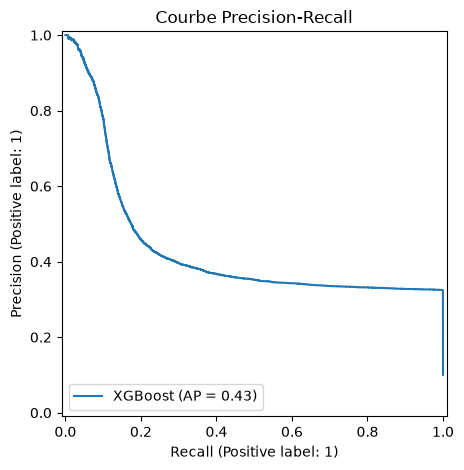

In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, PrecisionRecallDisplay
)

y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

pr_auc  = average_precision_score(y_val, y_pred_proba)

print(f"PR-AUC:{pr_auc:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=['Normal', 'Fraude']))


PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba, name="XGBoost")
plt.title("Courbe Precision-Recall")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    report = classification_report(y_val, y_pred_t, target_names=['Normal', 'Fraude'], output_dict=True)
    fraude = report['Fraude']
    print(f"Seuil {t} precision={fraude['precision']:.2f}  recall={fraude['recall']:.2f}  f1={fraude['f1-score']:.2f}")

Seuil 0.1 precision=0.32  recall=1.00  f1=0.49
Seuil 0.2 precision=0.32  recall=1.00  f1=0.49
Seuil 0.3 precision=0.32  recall=1.00  f1=0.49
Seuil 0.4 precision=0.32  recall=1.00  f1=0.49
Seuil 0.5 precision=0.32  recall=1.00  f1=0.49
Seuil 0.6 precision=0.32  recall=1.00  f1=0.49
Seuil 0.7 precision=0.32  recall=1.00  f1=0.49


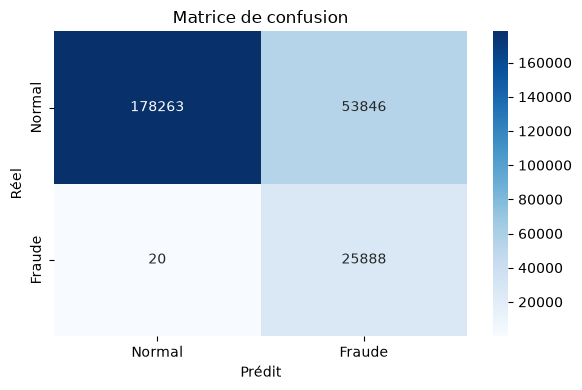

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

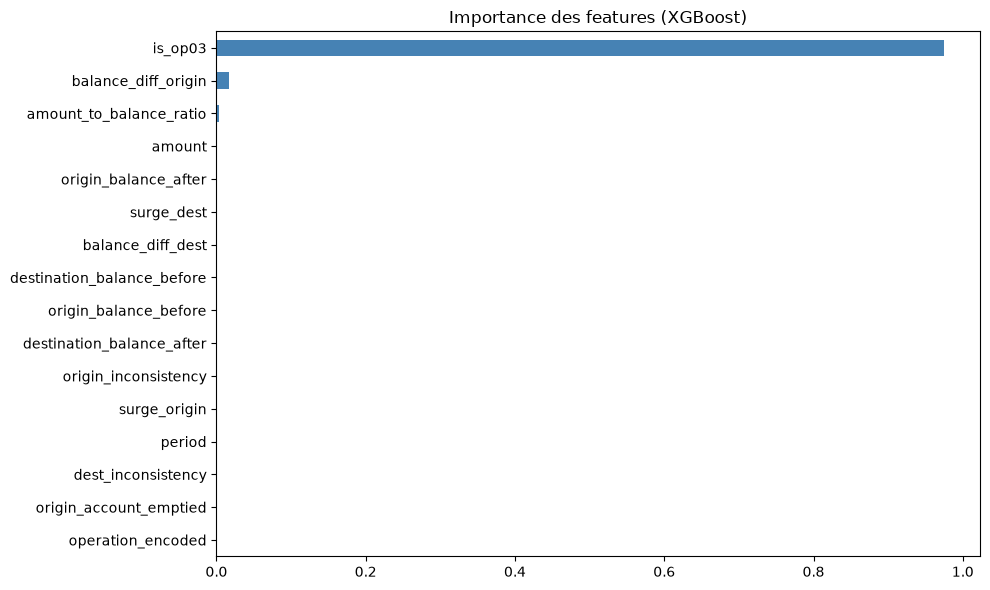

In [ ]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Importance des features (XGBoost)')
plt.tight_layout()
plt.show()

In [ ]:
df_test = pd.read_csv("../data/raw/test.csv")

df_test['balance_diff_origin'] = df_test['origin_balance_after'] - df_test['origin_balance_before']
df_test['balance_diff_dest'] = df_test['destination_balance_after'] - df_test['destination_balance_before']

df_test['origin_inconsistency'] = abs(
    (df_test['origin_balance_before'] - df_test['amount']) - df_test['origin_balance_after']
)
df_test['dest_inconsistency'] = abs(
    (df_test['destination_balance_before'] + df_test['amount']) - df_test['destination_balance_after']
)

df_test['origin_account_emptied']  = (df_test['origin_balance_after'] == 0).astype(int)
df_test['amount_to_balance_ratio'] = df_test['amount'] / (df_test['origin_balance_before'] + 1)
df_test['is_op03'] = (df_test['operation'] == 'op_03').astype(int)

operation_mapping = {'op_05': 0, 'op_03': 1, 'op_04': 2, 'op_02': 3, 'op_01': 4}
df_test['operation_encoded'] = df_test['operation'].map(operation_mapping)
df_test['surge_origin'] = df_test.groupby(['origin_account', 'period'])['id'].transform('count')
df_test['surge_dest']   = df_test.groupby(['destination_account', 'period'])['id'].transform('count')

features = [
    'period', 'amount', 'is_op03', 'operation_encoded',
    'origin_balance_before', 'origin_balance_after',
    'destination_balance_before', 'destination_balance_after',
    'balance_diff_origin', 'balance_diff_dest',
    'origin_inconsistency', 'dest_inconsistency',
    'origin_account_emptied', 'amount_to_balance_ratio',
    'surge_origin', 'surge_dest',   # ← ajoute ces deux
]

X_test = df_test[features]
print(X_test.shape)

(430100, 16)


In [ ]:
test_proba = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],
    'target': test_proba
})

submission.to_csv("../submissions/submission_xgb_v1.csv", index=False)
print(submission.head(10))
print(f"\nFichier sauvegardé : {submission.shape[0]} lignes")

                     id    target
0  dtf_0000001_08a8a524  0.000002
1  dtf_0000002_ae0d3769  0.791215
2  dtf_0000003_843bab7c  0.791476
3  dtf_0000004_91643844  0.000002
4  dtf_0000005_17bd9a08  0.788289
5  dtf_0000006_252a6318  0.000002
6  dtf_0000007_52b0ffae  0.000002
7  dtf_0000008_c37743d9  0.000002
8  dtf_0000009_bff3cf50  0.786569
9  dtf_0000010_7f815b93  0.788399

Fichier sauvegardé : 430100 lignes
